# Character types: archetype + social class × abstractness

Joins Sonnet's `character_type` task (per-character archetypes + social_class) with the social_network task's per-character descriptions. Two priorities for Ch5:

- **P1**: Does char description abstractness track the Pavel idealist→synthesis→anti-idealist axis at the archetype level?
- **P2**: Does the titled_nobility vs untitled_gentry split (which qwen's tags couldn't surface in nb15) show meaningful diachronic structure?

Then P3 (within-archetype concretization across centuries) and P4 (archetype × plot_genre cross-tab).

Data prep: 1,391 texts × ~52 chars/text = 73K characters. Per-character abstractness from `score_psg` over (descriptions + intro_text + notes), negated so + = abstract. Cached at `data/social_networks/character_types_scored.csv`.

In [1]:
import os
import pandas as pd
import numpy as np
import plotnine as p9
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as mcm
from collections import Counter

plt.rcParams['figure.dpi'] = 110
DROPBOX_FIGS = os.path.expanduser('~/Dropbox/Prof/Books/AbsLitHist/book/figures')

ch = pd.read_csv('../data/social_networks/character_types_scored.csv')
ch['archetypes'] = ch['archetypes'].fillna('').apply(lambda s: s.split('|') if s else [])
ch = ch[ch['char_abs'].notna() & ch['year'].notna()].copy()
ch['year'] = ch['year'].astype(int)
ch['century'] = (ch['year'] // 100 * 100).astype(int)
print(f'Characters with abs + year: {len(ch):,}, texts: {ch["source"].nunique():,}')
print(f'Year range: {ch["year"].min()}–{ch["year"].max()}')
print(f'Century distribution:')
print(ch.groupby('century').size().to_string())

Characters with abs + year: 71,764, texts: 1,370
Year range: 1477–2011
Century distribution:
century
1400      653
1500     6107
1600    17808
1700    13372
1800    12928
1900    20298
2000      598


## P1. Char description abstractness × archetype on the Pavel axis

Hypothesis: idealist archetypes (beautiful_soul, exceptional_being, persecuted_innocent, pharmakos) have most abstract descriptions; anti-idealist archetypes (picaro, fallible_everyman) have most concrete; synthesis archetypes (fallible_virtuous, innocent_child) in between.

Multi-label: explode characters to (character × archetype) rows, so each character contributes to all archetypes it carries.

Exploded char×archetype rows: 74,457

Archetype mean abstractness (n>=200, sorted by abs):
          archetype      pavel_axis    n  mean_abs    se
     beautiful_soul        idealist 2413     0.397 0.010
    reformed_sinner       synthesis  518     0.387 0.021
             mentor       synthesis 6539     0.365 0.006
  exceptional_being        idealist 2141     0.342 0.010
             tyrant   anti_idealist 5286     0.318 0.007
             alazon frye_structural 9473     0.312 0.005
             suitor       synthesis 2586     0.309 0.008
  fallible_virtuous       synthesis 1417     0.305 0.012
              rival   anti_idealist 1156     0.303 0.013
               rake   anti_idealist 1464     0.290 0.011
    virtuous_maiden        idealist 1533     0.273 0.011
  fallible_everyman   anti_idealist 4799     0.258 0.007
persecuted_innocent        idealist 2856     0.255 0.009
              eiron frye_structural 2030     0.227 0.011
           coquette   anti_idealist 1541     0.223 0.0


Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/character_types_archetype_abstractness.png


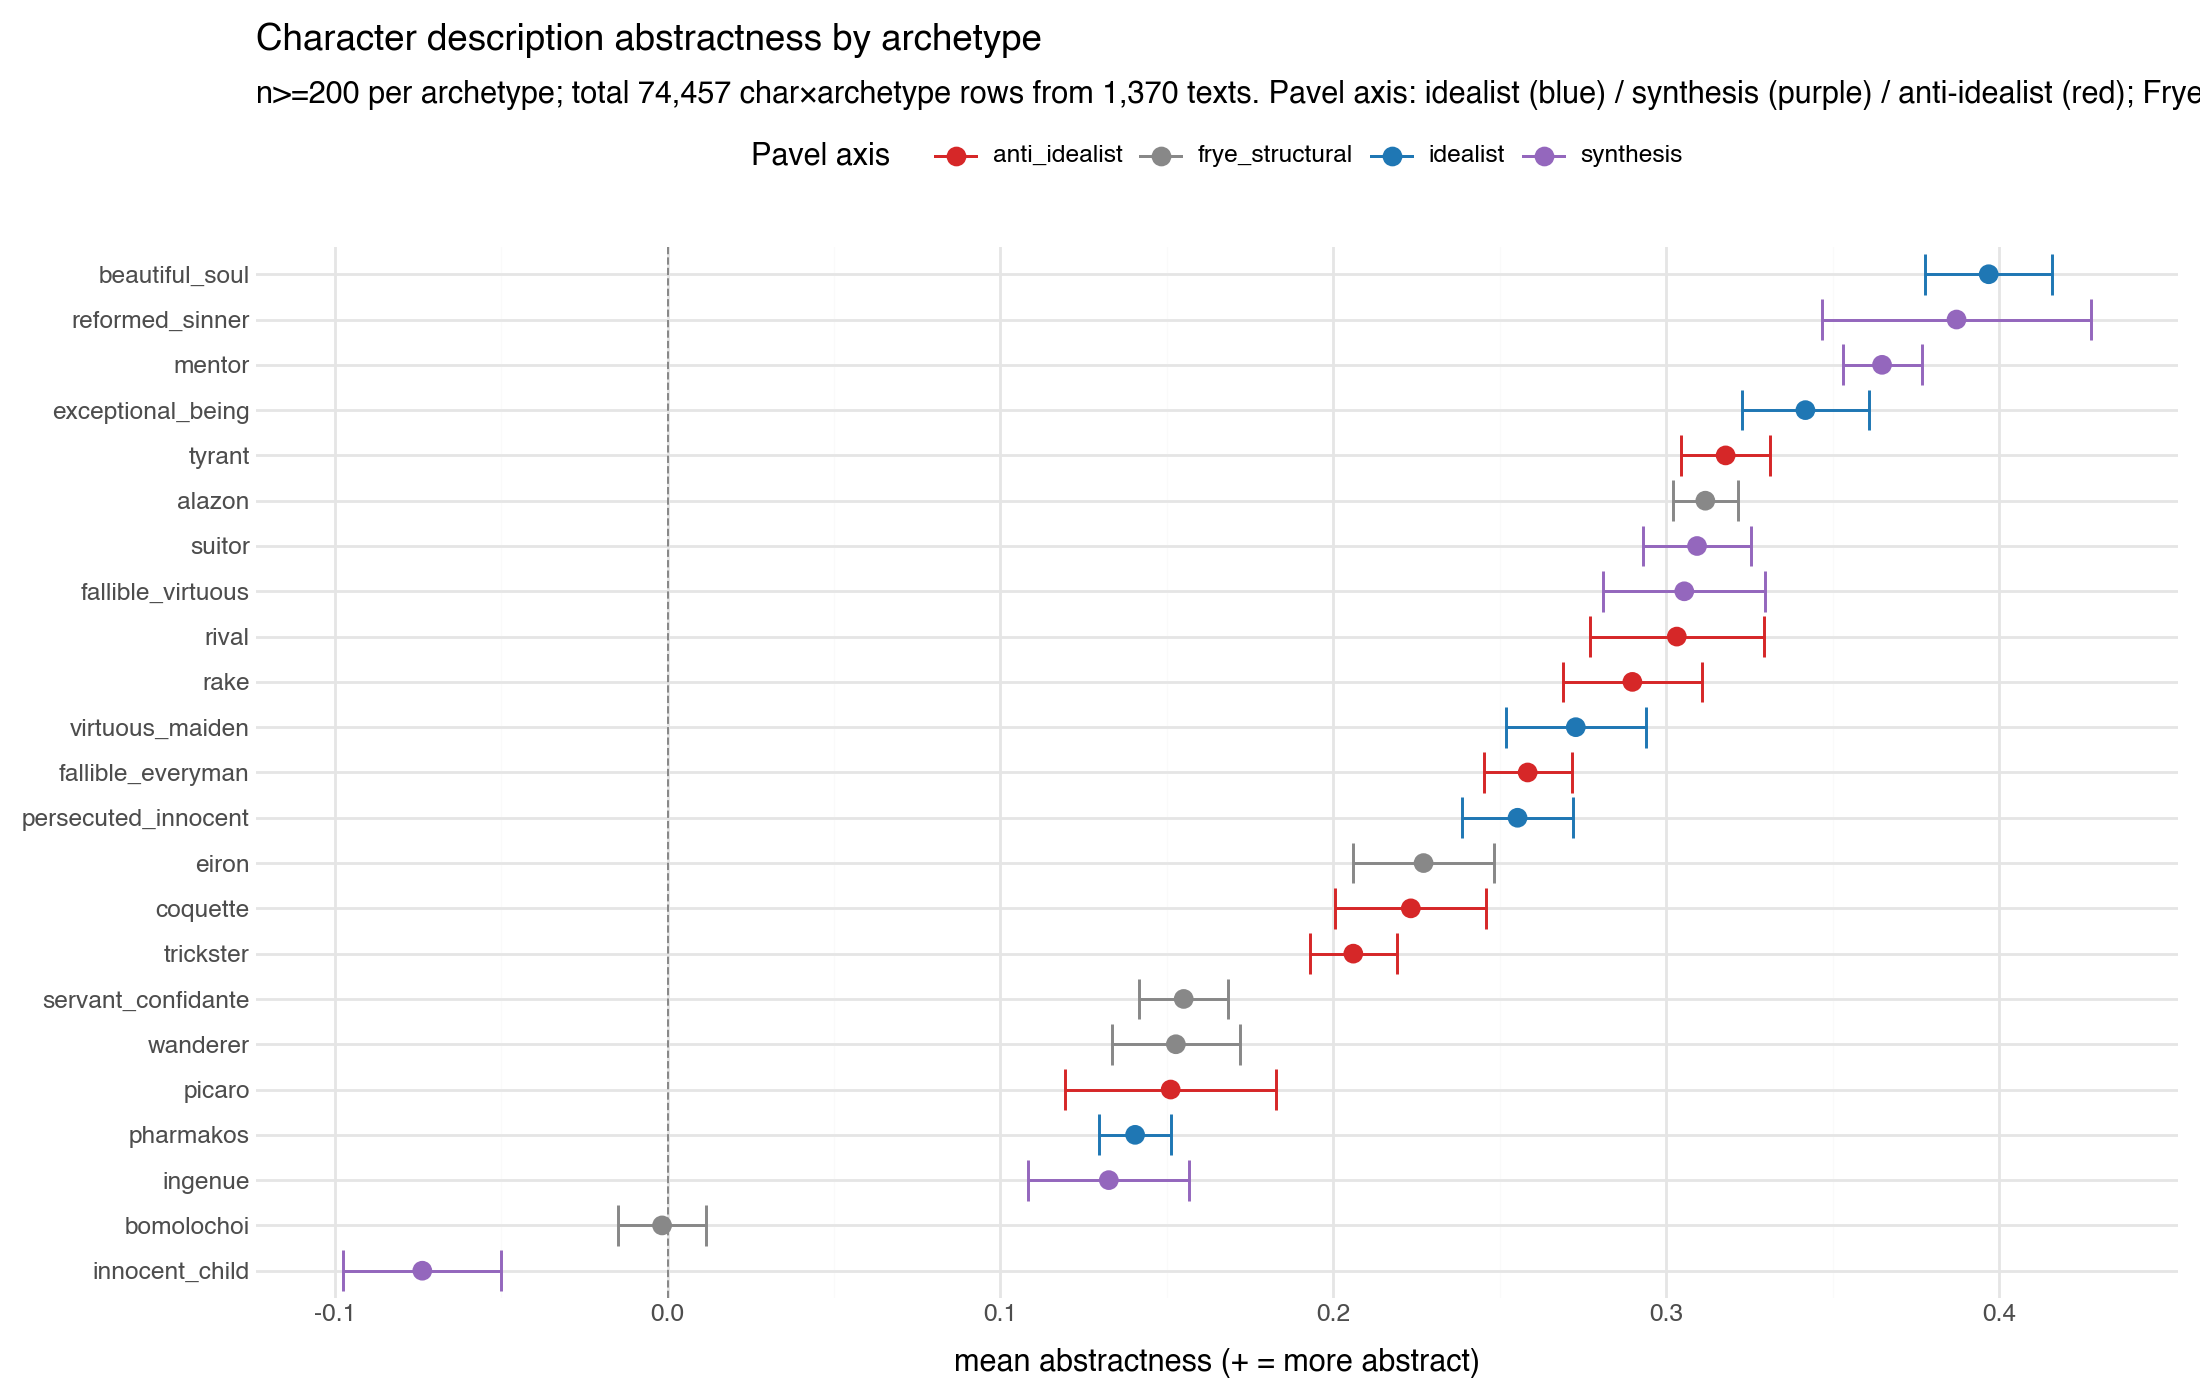

In [2]:
# Pavel-axis grouping. Tags assigned based on Pavel's tradition mapping +
# Frye structural types where applicable.
PAVEL_AXIS = {
    'idealist':     ['beautiful_soul', 'exceptional_being', 'persecuted_innocent',
                     'pharmakos', 'virtuous_maiden'],
    'synthesis':    ['fallible_virtuous', 'innocent_child', 'reformed_sinner',
                     'mentor', 'ingenue', 'suitor'],
    'anti_idealist': ['picaro', 'fallible_everyman', 'rake', 'trickster',
                      'coquette', 'rival', 'tyrant'],
    'frye_structural': ['alazon', 'eiron', 'bomolochoi', 'wanderer',
                        'servant_confidante'],
}
axis_lookup = {a: k for k, arr in PAVEL_AXIS.items() for a in arr}

# Explode
rows = []
for _, r in ch.iterrows():
    if not r['archetypes']:
        continue
    for a in r['archetypes']:
        rows.append({'source': r['source'], 'name': r['name'],
                     'archetype': a, 'pavel_axis': axis_lookup.get(a, 'other'),
                     'char_abs': r['char_abs'], 'year': r['year'],
                     'century': r['century']})
expl = pd.DataFrame(rows)
print(f'Exploded char×archetype rows: {len(expl):,}')

# Mean abs per archetype, with axis label
arch_stats = (expl.groupby('archetype').agg(
    n=('char_abs', 'count'),
    mean_abs=('char_abs', 'mean'),
    se=('char_abs', 'sem'),
    pavel_axis=('pavel_axis', 'first'),
).reset_index())
arch_stats = arch_stats[arch_stats['n'] >= 200].copy()
arch_stats['lo'] = arch_stats['mean_abs'] - 1.96 * arch_stats['se']
arch_stats['hi'] = arch_stats['mean_abs'] + 1.96 * arch_stats['se']
arch_stats = arch_stats.sort_values('mean_abs', ascending=False)
print('\nArchetype mean abstractness (n>=200, sorted by abs):')
print(arch_stats[['archetype', 'pavel_axis', 'n', 'mean_abs', 'se']]
      .to_string(index=False, float_format='%.3f'))

# Axis-level summary
axis_stats = expl[expl['pavel_axis'] != 'other'].groupby('pavel_axis').agg(
    n=('char_abs', 'count'),
    mean_abs=('char_abs', 'mean'),
    se=('char_abs', 'sem'),
).reset_index().sort_values('mean_abs', ascending=False)
print('\nAxis-level summary:')
print(axis_stats.to_string(index=False, float_format='%.3f'))

AXIS_COLORS = {
    'idealist': '#1f77b4',
    'synthesis': '#9467bd',
    'anti_idealist': '#d62728',
    'frye_structural': '#888888',
    'other': '#cccccc',
}
arch_stats['archetype'] = pd.Categorical(arch_stats['archetype'],
                                          categories=arch_stats.sort_values('mean_abs')['archetype'].tolist(),
                                          ordered=True)

p_p1 = (p9.ggplot(arch_stats, p9.aes(x='mean_abs', y='archetype', color='pavel_axis'))
        + p9.geom_vline(xintercept=0, color='#888888', linetype='dashed', size=0.4)
        + p9.geom_errorbarh(p9.aes(xmin='lo', xmax='hi'), height=0.0, size=0.6)
        + p9.geom_point(size=3.0)
        + p9.scale_color_manual(values=AXIS_COLORS)
        + p9.labs(
            title='Character description abstractness by archetype',
            subtitle=f'n>=200 per archetype; total {len(expl):,} char×archetype rows from {ch["source"].nunique():,} texts. '
                     f'Pavel axis: idealist (blue) / synthesis (purple) / anti-idealist (red); Frye structural in grey.',
            x='mean abstractness (+ = more abstract)', y='', color='Pavel axis',
        )
        + p9.theme_minimal()
        + p9.theme(figure_size=(11, 7), legend_position='top'))
out = os.path.join(DROPBOX_FIGS, 'character_types_archetype_abstractness.png')
p_p1.save(out, dpi=300, verbose=False)
print(f'\nSaved to {out}')
p_p1

## P2. Social class composition C16 → C20 with titled vs gentry split

qwen's class tags collapsed all aristocracy into one bucket (95% generic 'aristocrat'/'noble'); Sonnet's separates royalty / titled_nobility / untitled_gentry. Now we can ask:
1. **Composition over time**: does titled_nobility share rise into C19 (Trollope's Barchester), or stay flat?
2. **Class-abstractness gradient**: does the 'abstract description as class privilege' finding (from char-intros) hold up with cleaner tags?
3. **Gentry vs nobility**: nb15 couldn't distinguish — does the literary record privilege one over the other diachronically?

Characters per century:
century
1400      653
1500     6107
1600    17808
1700    13372
1800    12928
1900    20298
2000      598

Top classes: ['untitled_gentry', 'professional', 'titled_nobility', 'servant', 'royalty', 'merchant', 'clergy', 'laborer', 'artisan', 'criminal']


/Users/rj416/github/abslithists/abstraction/.venv/lib/python3.10/site-packages/plotnine/_mpl/utils.py:26: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.
/Users/rj416/github/abslithists/abstraction/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:695: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.



Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/character_types_class_composition_C15_C20.png

% of century's characters by class:
century           C15   C16   C17   C18   C19   C20   C21
social_class                                             
untitled_gentry  19.8  18.4  17.6  26.4  21.7  10.6   6.2
professional      3.8   7.9   8.6  12.8  14.9  22.7  47.8
titled_nobility  10.0  11.0  14.8  13.6  12.8   1.9   0.0
servant           2.0   4.5   6.8   8.8  10.1   4.5   6.5
royalty          23.3  18.3  11.8   3.8   1.5   0.7   0.2
merchant          1.1   2.5   3.9   5.6   6.3   6.2   6.0
clergy            8.9   4.3   5.8   4.9   5.9   2.7   2.8
laborer           1.1   1.6   1.5   1.7   6.1   8.7   4.2
artisan           0.6   2.8   3.2   3.1   5.8   4.9   3.8
criminal          0.3   2.5   2.7   2.5   1.6   3.3   4.3


Class abstractness gradient (overall):
                     n  mean_abs     se
social_class                           
royalty           4200     0.443  

/Users/rj416/github/abslithists/abstraction/.venv/lib/python3.10/site-packages/plotnine/_mpl/utils.py:26: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.
/Users/rj416/github/abslithists/abstraction/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:695: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.


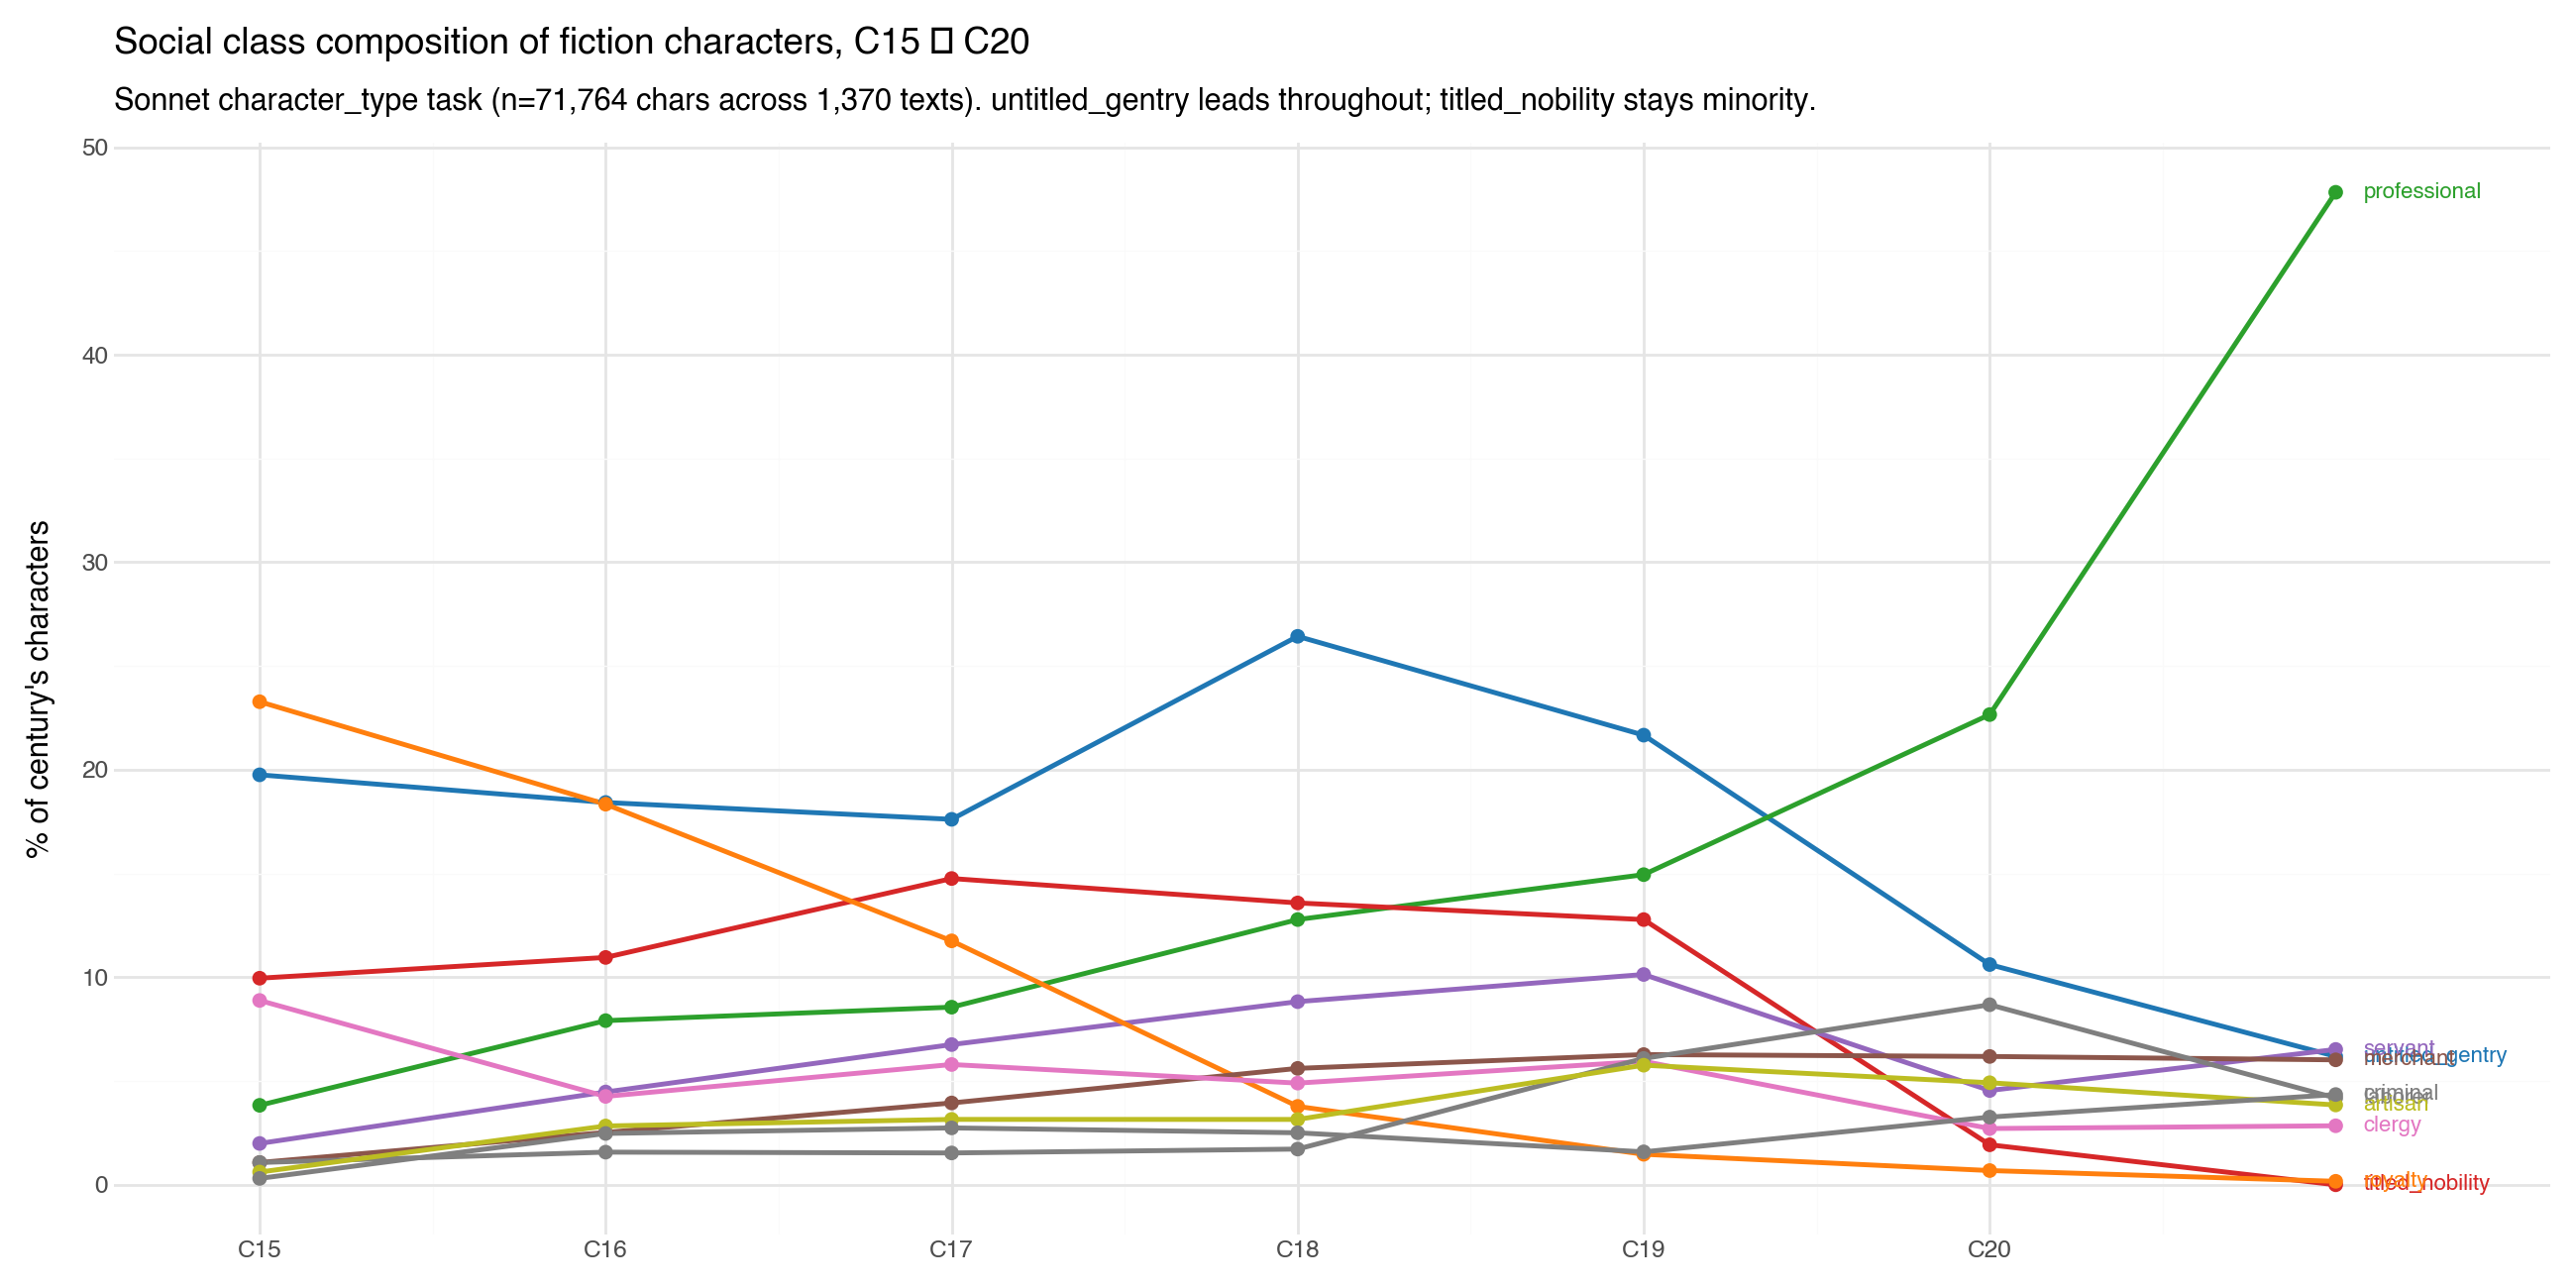

In [3]:
# Class composition by century. Single-label (each char has one class).
# Treat unknown/missing as 'unknown'; we plot only the substantively-tagged classes.
ch['social_class'] = ch['social_class'].fillna('unknown')

# Total characters per century (denominator)
tot_by_cent = ch.groupby('century').size()
print('Characters per century:')
print(tot_by_cent.to_string())

# Top classes
top_classes = (ch['social_class'].value_counts()
               .drop('unknown', errors='ignore').head(10).index.tolist())
print(f'\nTop classes: {top_classes}')

# Composition: % of each century's characters in each class
comp_rows = []
for cent, n_cent in tot_by_cent.items():
    if n_cent < 100:
        continue
    for cls in top_classes:
        n = ((ch['century'] == cent) & (ch['social_class'] == cls)).sum()
        comp_rows.append({
            'century_year': cent + 50, 'century': f'C{cent//100+1}',
            'social_class': cls, 'n': n, 'pct': n / n_cent * 100,
        })
comp = pd.DataFrame(comp_rows)

# Order classes by overall abundance
comp['social_class'] = pd.Categorical(comp['social_class'], categories=top_classes, ordered=True)

# Highlight titled_nobility vs untitled_gentry
PALETTE = {
    'untitled_gentry':  '#1f77b4',
    'titled_nobility':  '#d62728',
    'professional':     '#2ca02c',
    'royalty':          '#ff7f0e',
    'servant':          '#9467bd',
    'merchant':         '#8c564b',
    'clergy':           '#e377c2',
    'laborer':          '#7f7f7f',
    'artisan':          '#bcbd22',
    'soldier':          '#17becf',
}

labels = comp.sort_values('century_year').groupby('social_class', observed=True, as_index=False).last()

p_p2 = (p9.ggplot(comp, p9.aes(x='century_year', y='pct',
                                group='social_class', color='social_class'))
        + p9.geom_line(size=1.0)
        + p9.geom_point(size=2.0)
        + p9.geom_text(p9.aes(label='social_class'), data=labels,
                       nudge_x=8, ha='left', size=8, fontweight='bold',
                       show_legend=False)
        + p9.scale_x_continuous(breaks=[1450, 1550, 1650, 1750, 1850, 1950],
                                labels=['C15','C16','C17','C18','C19','C20'],
                                limits=(1440, 2080))
        + p9.scale_color_manual(values=PALETTE)
        + p9.labs(
            title='Social class composition of fiction characters, C15 → C20',
            subtitle=f'Sonnet character_type task (n={len(ch):,} chars across {ch["source"].nunique():,} texts). '
                     f'untitled_gentry leads throughout; titled_nobility stays minority.',
            x='', y='% of century\'s characters', color='',
        )
        + p9.theme_minimal()
        + p9.theme(figure_size=(13, 6.5), legend_position='none'))
out = os.path.join(DROPBOX_FIGS, 'character_types_class_composition_C15_C20.png')
p_p2.save(out, dpi=300, verbose=False)
print(f'\nSaved to {out}')

# Print the table
tbl = comp.pivot(index='social_class', columns='century', values='pct').round(1)
tbl = tbl.loc[top_classes]
print('\n% of century\'s characters by class:')
print(tbl.to_string())

# Class abstractness gradient (overall)
print('\n\nClass abstractness gradient (overall):')
cls_abs = (ch[ch['social_class'].isin(top_classes)].groupby('social_class')
           .agg(n=('char_abs','count'), mean_abs=('char_abs','mean'), se=('char_abs','sem'))
           .sort_values('mean_abs', ascending=False))
print(cls_abs.round(3).to_string())

p_p2